In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_classes=2,
    n_informative=3,
    n_redundant=0,
    random_state=42
)

print(X.shape)  # (100, 5)
print(y.shape)  # (100,)
print(y)        # 0 or 1

df = pd.DataFrame(
    X,
    columns=["X1", "X2", "X3", "X4", "X5"]
)
df["y"] = y

print(df.info())
print(df.describe())

VX = np.asarray(df[["X1", "X2", "X3", "X4", "X5"]], dtype=np.float32)
Vy = np.asarray(df["y"], dtype=np.float32)

(100, 5)
(100,)
[0 1 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0
 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 0 0
 1 1 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0]
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      100 non-null    float64
 1   X2      100 non-null    float64
 2   X3      100 non-null    float64
 3   X4      100 non-null    float64
 4   X5      100 non-null    float64
 5   y       100 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 4.8 KB
None
               X1          X2          X3          X4          X5           y
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean     0.029920   -0.074183   -0.386701   -0.045042    0.317645    0.500000
std      1.517747    0.943605    1.256708    1.051756    1.265298    0.502519
min     -4.233589   -2.30

In [2]:
def hypothesis(Vx, Vw, b):
    z = np.dot(Vx, Vw) + b
    return 1 / (1 + np.exp(-z))

def cost(Vw, b):
    m = len(VX)

    cost_sum = 0
    for i in range(m):
        Vx = VX[i]
        y = Vy[i]
        y_pred = hypothesis(Vx, Vw, b)
        loss = -(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        cost_sum += loss

    return cost_sum / m

def compute_gradients(Vw, b, lr):

    m = len(VX)
    dj_dw = np.zeros_like(Vw)    
    dj_db = 0
    for i in range(m):
        Vx = VX[i]
        y = Vy[i]
        y_pred = hypothesis(Vx, Vw, b)
        error = y_pred - y 

        dj_dw += error * Vx
        dj_db += error

    return Vw - ((lr * dj_dw) / m), b - ((lr * dj_db) / m)

iteration 0 0.44580233
iteration 100 0.39832512
iteration 200 0.36644223
iteration 300 0.34415665
iteration 400 0.32800362
iteration 500 0.31588963
iteration 600 0.30651116
iteration 700 0.2990386
iteration 800 0.2929324
iteration 900 0.28783476
iteration 1000 0.28350267
iteration 1100 0.27976713
iteration 1200 0.27650726
iteration 1300 0.27363476
iteration 1400 0.27108294
iteration 1500 0.26880124
iteration 1600 0.26674953
iteration 1700 0.26489586
iteration 1800 0.2632144
iteration 1900 0.26168364
iteration 2000 0.26028597
iteration 2100 0.25900617
iteration 2200 0.25783148
iteration 2300 0.25675094
iteration 2400 0.25575483
iteration 2500 0.25483507
iteration 2600 0.2539839
iteration 2700 0.25319523
iteration 2800 0.25246343
iteration 2900 0.25178343
iteration 3000 0.25115037
iteration 3100 0.25056064
iteration 3200 0.25001037
iteration 3300 0.24949639
iteration 3400 0.24901554
iteration 3500 0.24856547
iteration 3600 0.24814385
iteration 3700 0.24774802
iteration 3800 0.24737656
it

Text(0.5, 1.0, 'Learning Curve')

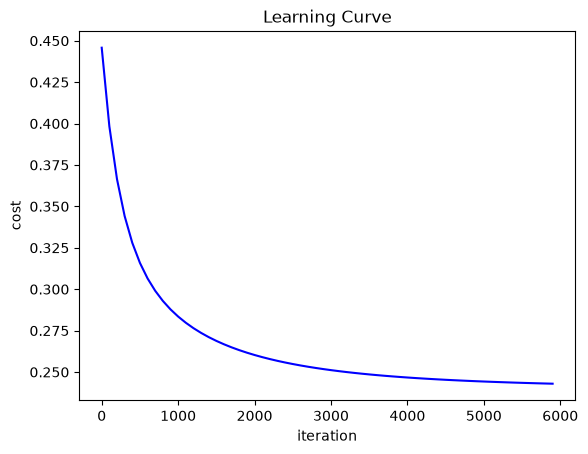

In [3]:
Vw = np.ones_like(VX[0])
b = 1
iteration = 10000
lr = 0.01
initial_cost =  cost(Vw, b)


iter_his = []
cost_his = []

for i in range(iteration):
        new_Vw, new_b = compute_gradients(Vw, b, lr)
        new_cost = cost(new_Vw, new_b)

        if abs(new_cost - initial_cost) < 1e-6:
              break

        if (i % 100 == 0):
            print('iteration', i, new_cost)
            iter_his.append(i)
            cost_his.append(new_cost) 

        initial_cost = new_cost
        Vw, b = new_Vw, new_b

plt.plot(iter_his, cost_his, c='b')
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Learning Curve')